In [116]:
#source TFAvenv/bin/activate (launching and exiting the virtual environment containing the required modules, stored in the working directory)
#TFAvenv/bin/python your_script.py - for running a script in the virtual environment
#source deactivate

#import all the libraries needed
from import_dep import *
import importlib

# import every PMU import class
import PMU
importlib.reload(PMU)
from PMU import (PMUdata, FatigueRun, PMUContainer,
                 Keithley_PUND, Keithley_Haoran_PUND, Keithley_Custom, Keithley_DHM,
                 AixACCT_PUND, AixACCT_DHM, AixACCT_Fatigue,
                 merge_PMU)

# import every transform and plotting function
import PMU_functions
importlib.reload(PMU_functions)
from PMU_functions import (extract_pund, extract_dhm, extract_fatigue,
                           plot_PUND, plot_PUND_polarisation, plot_DHM,
                           plot_fatigue, plot_custom_waveform,
                           update_plot_string)

# import custom plot style
import plot_style
importlib.reload(plot_style)
from plot_style import set_plot_style

# Root directories
root_KEI = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/'
root_AIX = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/AixAcct/'

# --- Keithley 4200A, JT147: custom waveform (3-terminal FeFET) ---
data_JT147   = root_KEI + 'JT147/Data'
output_JT147 = root_KEI + 'JT147/Output'

# --- aixACCT, JT147: PUND ---
data_JT147_AIX   = root_AIX + 'JT147/Data'
output_JT147_AIX = root_AIX + 'JT147/Output'

# --- aixACCT, SM04: PUND + DHM + fatigue all in one folder ---
data_SM04   = root_AIX + 'SM04/Data'
output_SM04 = root_AIX + 'SM04/Output'

# --- aixACCT, SM06: PUND + DHM + fatigue all in one folder ---
data_SM06   = root_AIX + 'SM06/Data'
output_SM06 = root_AIX + 'SM06/Output'


# --- Keithley, H03C5: PUND exported by Haoran's script ---
data_H03C5   = root_KEI + 'H03C5/Data/PUND'
output_H03C5 = root_KEI + 'H03C5/Output'

### Plotting and Output Variables
export_data = False        # True writes figures + summary CSVs to the Output folder
fig_format = 'svg'         # 'svg' | 'png' | 'tiff' | 'pdf'
plot_transparency = True   # transparent figure backgrounds

fig_size = set_plot_style(export_data=export_data, use_tex=True, markersize=0.1)


# PMU / Ferroelectric Analysis

Every PMU measurement type and every instrument, in one place, with the full
option list for each call written out and commented so it can be switched on
without looking anything up.

| Section | Sample | Instrument | Class |
|---|---|---|---|
| Custom waveform (3-terminal FeFET) | JT147 | Keithley 4200A | `Keithley_Custom` |
| PUND | JT147 | aixACCT | `AixACCT_PUND` |
| PUND + DHM + fatigue | SM04 | aixACCT | `AixACCT_PUND` / `AixACCT_DHM` / `AixACCT_Fatigue` |
| PUND | H03C5 | Keithley, Haoran export | `Keithley_Haoran_PUND` |

**Importing also processes.** Each class runs `_load_data()` then
`_transform_data()`, so the moment a constructor returns, every run already
carries its `.pund` / `.dhm` loop and its `.extracted_params`. Anything that
changes the transform (`med_filt`, `p_pulse`, `centre_branches`, `loop`,
`Pr_mode`) belongs on the **importer**; passing it to a plot call still works
and re-extracts, but then the stored object and the figure can disagree.

    obj[0].raw_data           # as measured
    obj[0].metadata           # everything from the file header + filename
    obj[0].pund / obj[0].dhm  # the processed loop
    obj[0].extracted_params   # Pr, 2Pr, Vc, Ec, imprint, Qsw
    obj[0].instrument_params  # what the instrument itself reported
    obj.summary_table()       # one row per run


# Custom Waveform --- Pulsed FeFET (3-terminal)

The Keithley 4200A custom-waveform module drives channel 2 into the gate with a
PUND-like pulse train while channel 1 monitors the drain. This is the only
genuinely 3-terminal measurement here: the ferroelectric is the gate dielectric
and the readout is the channel, so what is observed is the effect of the
polarisation state on the channel rather than the switching charge itself.

A working FeFET shows the drain current settling to **two distinct levels** after
positive and negative gate pulses, and holding them once the pulse is removed ---
that separation is the memory window. A current that relaxes back to a single
level between pulses means the polarisation is not being retained, or that what
looks like switching is really trapping.


In [46]:
## Import - Keithley 4200A custom waveform, JT147
# ch2 = gate (PUND-like pulses), ch1 = drain

custom_JT147 = Keithley_Custom(data_JT147,
    #folder_name       = None,     # optional sub-folder under root_folder
    #electrode_area    = None,     # m^2; overrides the area stored on each run
    #film_thickness_nm = None,     # nm; adds the top E-field axis and Ec
     sample            = 'JT147',  # short label prefix used in legends
    #verbose           = True,     # print the load summary
    )

custom_JT147.summary_table()


Keithley_Custom: loaded 1 CUSTOM run(s) from /Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/JT147/Data


,run,file,label,source_file,sheet,clarius_run
0,0,JT147 Ferroelectric_tests_13 customwaveform_8#...,JT147 Run9,JT147 Ferroelectric_tests_13 customwaveform_8#...,Data,9


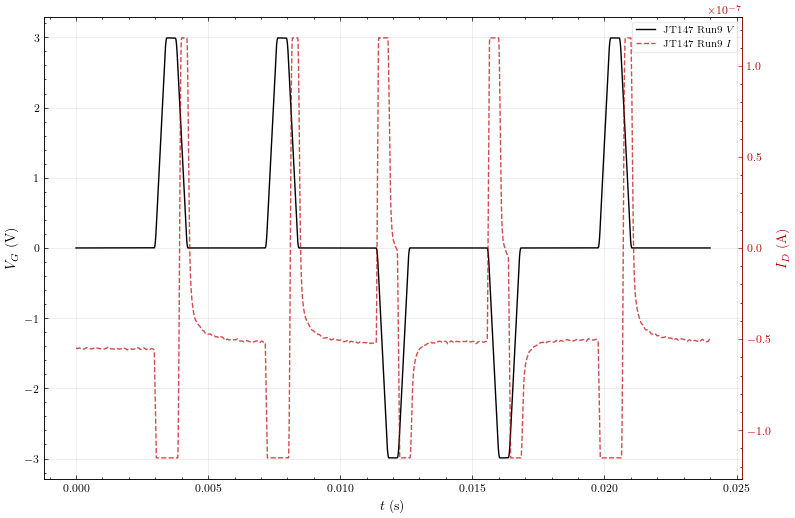

In [47]:
## Gate voltage and drain current vs time

fig_custom = plot_custom_waveform([custom_JT147],
    #run_nums          = None,               # run numbers to plot; None = all
     v_channel         = 'V_Ch2',            # 'V_Ch1' | 'V_Ch2' - which channel drives the left axis
     i_channel         = 'I_Ch1',            # 'I_Ch1' | 'I_Ch2' - which channel drives the right axis
    #x_lim             = None,               # (min, max) x-axis limits
    #y_lim_left        = None,               # (min, max) left axis - polarisation / voltage
    #y_lim_right       = None,               # (min, max) right axis - current
     med_filt          = 91,                 # median-filter kernel on I (odd int) - kills spikes
     sigma_filt        = 91,                 # boxcar window on I - smooths
    #display_points    = False,              # draw a marker at every sample
    #line_width        = None,               # override the style line width
    #markersize        = None,               # override the style marker size
    #plot_key          = True,               # show the legend
    #plot_title        = None,
     export_data       = export_data,        # write the figure (and summary CSV) to output_PMU
     output_PMU        = output_JT147,       # output folder
     fig_name          = 'JT147',            # prefix for the exported file name
     fig_format        = fig_format,         # 'svg' | 'png' | 'tiff' | 'pdf'
     plot_transparency = plot_transparency,  # transparent figure background
    #show              = True,               # render in the notebook; False just returns the figure
    )


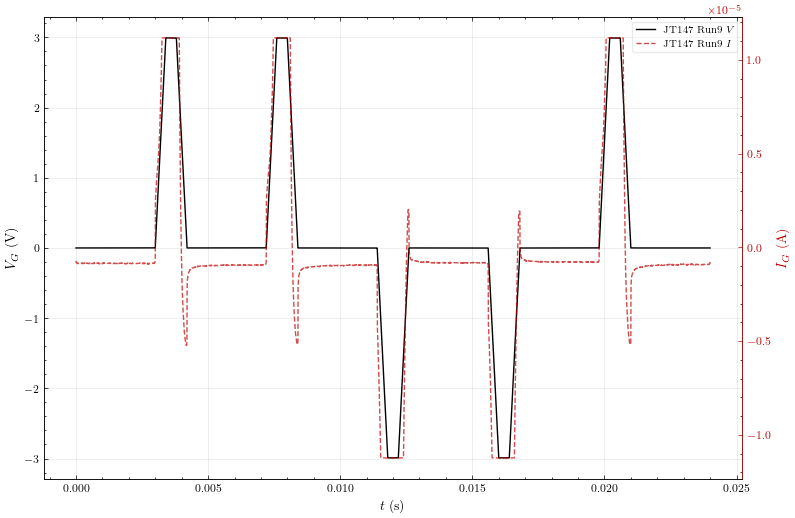

In [48]:
## Gate leakage during the same pulse train
# Any feature in the drain trace mirrored here is gate leakage, not switching.

fig_leak = plot_custom_waveform([custom_JT147],
    #run_nums          = None,               # run numbers to plot; None = all
     v_channel         = 'V_Ch2',            # 'V_Ch1' | 'V_Ch2' - which channel drives the left axis
     i_channel         = 'I_Ch2',            # 'I_Ch1' | 'I_Ch2' - which channel drives the right axis
    #x_lim             = None,               # (min, max) x-axis limits
    #y_lim_left        = None,               # (min, max) left axis - polarisation / voltage
    #y_lim_right       = None,               # (min, max) right axis - current
     med_filt          = 91,                 # median-filter kernel on I (odd int) - kills spikes
    #sigma_filt        = None,               # boxcar window on I - smooths
    #display_points    = False,              # draw a marker at every sample
    #line_width        = None,               # override the style line width
    #markersize        = None,               # override the style marker size
    #plot_key          = True,               # show the legend
    #plot_title        = None,
     export_data       = export_data,        # write the figure (and summary CSV) to output_PMU
     output_PMU        = output_JT147,       # output folder
     fig_name          = 'JT147_gate',       # prefix for the exported file name
     fig_format        = fig_format,         # 'svg' | 'png' | 'tiff' | 'pdf'
     plot_transparency = plot_transparency,  # transparent figure background
    #show              = True,               # render in the notebook; False just returns the figure
    )


# aixACCT --- PUND, sample JT147

Each `Table N` in the `.dat` file becomes one run; this file holds 10. The file
type is detected from its **contents**, not its name, so an export called
`NewPund.dat` is picked up just as `PundFile1.dat` is.

Area and thickness come from the file header. The aixACCT waveform is five
pulses, `P U N D P`: the fifth is a second positive switching pulse and is the
one used by default, because it follows `D` and so the film is definitively
down-poled before it. The first `P` has no such guarantee --- what it measures
depends on how the device was left by whatever ran before.


In [79]:
## Import - aixACCT PUND, JT147

pund_JT147 = AixACCT_PUND(data_JT147_AIX,
    #folder_name       = None,     # optional sub-folder under root_folder
    electrode_area    = np.pi*((40e-6)/2)**2,     # m^2; overrides the area stored on each run
    #film_thickness_nm = None,     # nm; adds the top E-field axis and Ec
     sample            = 'JT147',  # short label prefix used in legends
    #p_pulse           = 'last',   # 'last' | 'first' | 'both' - which P pairs with U
    #centre_branches   = True,     # re-reference each half about P = 0
    #med_filt          = None,     # median-filter kernel on I (odd int) - kills spikes
    #sigma_filt        = None,     # boxcar window on I - smooths
    #transform         = True,     # process on import; False imports the raw data only
    #verbose           = True,     # print the load summary
    )

pund_JT147.summary_table()[['run', 'file', 'label', 'Current Range']]


Note: 'JT147, Run0, T1, 2 V, 5000 Hz, td=1 ms' P-U - the switching and non-switching pulses differ by up to 0.116 V (6% of peak) once aligned in time. Usually sampling jitter between the two pulses on a steep ramp, which adds a little error to the subtraction; it matters more on coarsely sampled records.
Note: 'JT147, Run0, T1, 2 V, 5000 Hz, td=1 ms' N-D - the switching and non-switching pulses differ by up to 0.341 V (18% of peak) once aligned in time. Usually sampling jitter between the two pulses on a steep ramp, which adds a little error to the subtraction; it matters more on coarsely sampled records.
Note: 'JT147, Run1, T2, 2 V, 5000 Hz, td=1 ms' P-U - the switching and non-switching pulses differ by up to 0.116 V (6% of peak) once aligned in time. Usually sampling jitter between the two pulses on a steep ramp, which adds a little error to the subtraction; it matters more on coarsely sampled records.
Note: 'JT147, Run5, T6, 2 V, 500 Hz, td=1 ms' N-D - the switching and non-switchi

,run,file,label,Current Range
0,0,PundFile1.dat,"JT147, Run0, T1, 2 V, 5000 Hz, td=1 ms",8 (1uA)
1,1,PundFile1.dat,"JT147, Run1, T2, 2 V, 5000 Hz, td=1 ms",7 (10uA)
2,2,PundFile1.dat,"JT147, Run2, T3, 2 V, 500 Hz, td=1 ms",8 (1uA)
3,3,PundFile1.dat,"JT147, Run3, T4, 2 V, 500 Hz, td=1 ms",8 (1uA)
4,4,PundFile1.dat,"JT147, Run4, T5, 2 V, 500 Hz, td=1 ms",8 (1uA)
5,5,PundFile1.dat,"JT147, Run5, T6, 2 V, 500 Hz, td=1 ms",8 (1uA)
6,6,PundFile1.dat,"JT147, Run6, T7, 2 V, 500 Hz, td=1 ms",8 (1uA)
7,7,PundFile1.dat,"JT147, Run7, T8, 2 V, 500 Hz, td=100 ms",8 (1uA)
8,8,PundFile1.dat,"JT147, Run8, T9, 2 V, 500 Hz, td=1 s",8 (1uA)
9,9,PundFile1.dat,"JT147, Run9, T10, 2 V, 500 Hz, td=10 s",8 (1uA)


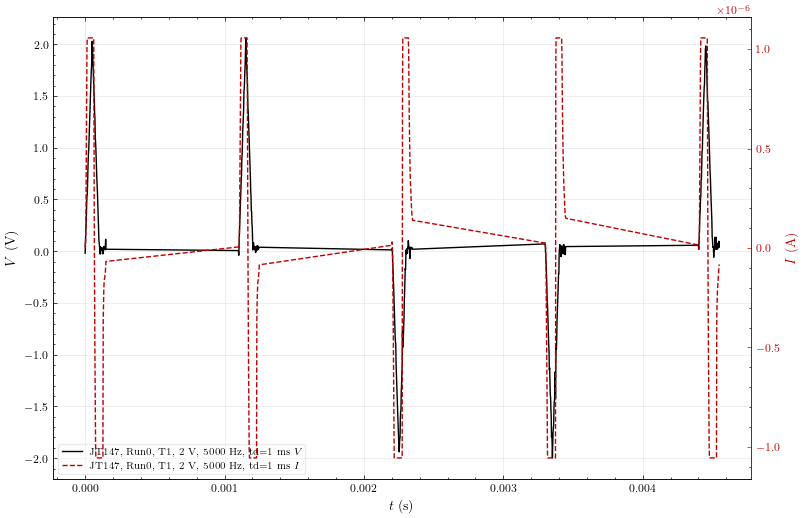

In [80]:
## Waveforms vs time - the pulse train as applied, before any subtraction

fig_pund_t = plot_PUND([pund_JT147],
     run_nums          = [0],                # run numbers to plot; None = all
    #x_lim             = None,               # (min, max) x-axis limits
    #y_lim_left        = None,               # (min, max) left axis - polarisation / voltage
    #y_lim_right       = None,               # (min, max) right axis - current
    #med_filt          = None,               # median-filter kernel on I (odd int) - kills spikes
    #sigma_filt        = None,               # boxcar window on I - smooths
    #display_points    = False,              # draw a marker at every sample
    #line_width        = None,               # override the style line width
    #markersize        = None,               # override the style marker size
    #plot_key          = True,               # show the legend
    #plot_title        = None,
     export_data       = export_data,        # write the figure (and summary CSV) to output_PMU
     output_PMU        = output_JT147_AIX,   # output folder
     fig_name          = 'JT147',            # prefix for the exported file name
     fig_format        = fig_format,         # 'svg' | 'png' | 'tiff' | 'pdf'
     plot_transparency = plot_transparency,  # transparent figure background
    #show              = True,               # render in the notebook; False just returns the figure
    )



PUND extracted parameters:
                              Dataset    Pr+      Qsw+    Vc+    Pr-       Qsw-     Vc-     Pr   2Pr    Vc  Vimprint   Ec+    Ec-    Ec  Eimprint
JT147, Run2, T3, 2 V, 500 Hz, td=1 ms 0.8843 2.222e-11 0.7438 -1.008 -2.534e-11 -0.8262 0.9462 1.892 0.785  -0.04118 371.9 -413.1 392.5    -20.59


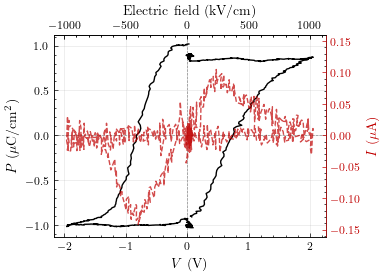

,Dataset,Pr+,Qsw+,Vc+,Pr-,Qsw-,Vc-,Pr,2Pr,Vc,Vimprint,Ec+,Ec-,Ec,Eimprint
0,"JT147, Run2, T3, 2 V, 500 Hz, td=1 ms",0.884255,2.222374e-11,0.743832,-1.008121,-2.533684e-11,-0.826189,0.946188,1.892375,0.785011,-0.041179,371.915993,-413.094649,392.505321,-20.589328


In [ ]:
## Switching polarisation loop
# Reads the loop built at import; nothing is recomputed here.

fig_pund_p, summary_JT147 = plot_PUND_polarisation([pund_JT147],
     run_nums          = [2],             # run numbers to plot; None = all
    #electrode_area    = None,               # m^2; overrides the area stored on each run
    #film_thickness_nm = None,               # nm; adds the top E-field axis and Ec
    #p_pulse           = None,               # 'last' | 'first' | 'both' - which P pairs with U
    #centre_branches   = True,               # re-reference each half about P = 0
    #align_zero        = True,               # put I = 0 level with P = 0 on the twin axis
    #x_lim             = None,               # (min, max) x-axis limits
    #y_lim_left        = None,               # (min, max) left axis - polarisation / voltage
    #y_lim_right       = None,               # (min, max) right axis - current
    #med_filt          = None,               # median-filter kernel on I (odd int) - kills spikes
    #sigma_filt        = None,               # boxcar window on I - smooths
    #display_points    = False,              # draw a marker at every sample
    #line_width        = None,               # override the style line width
    #markersize        = None,               # override the style marker size
    plot_key          = False,               # show the legend
    #plot_title        = None,
    #print_summary     = True,               # print the extracted-parameter table
     export_data       = True, #export_data,        # write the figure (and summary CSV) to output_PMU
     output_PMU        = output_JT147_AIX,   # output folder
     fig_name          = 'JT147',            # prefix for the exported file name
     fig_format        = fig_format,         # 'svg' | 'png' | 'tiff' | 'pdf'
     plot_transparency = plot_transparency,  # transparent figure background
    #show              = True,               # render in the notebook; False just returns the figure
    )

# Run 0 is a flat, failed measurement - swap it in to see what that
# looks like against a working one. All 10 tables are available.
summary_JT147


# aixACCT --- PUND + DHM + Fatigue, sample SM04

This folder holds all three measurement types. Each class scans it and takes
only the files belonging to its own type, so it opens as three objects.

* `PundFile1.dat`   -> `AixACCT_PUND`, 4 runs
* `HysterFile1.dat` -> `AixACCT_DHM`, 14 runs
* `FatigueFile_1e8.dat` -> `AixACCT_Fatigue`, 2 runs (57 loops between them)

**PUND vs DHM.** PUND subtracts the non-switching pulse from the switching one,
so it isolates the switching charge and gives a quantitative $P_r$. A DHM loop
cannot be separated that way, so its $P_r$ would silently include leakage --- the
values reported for DHM below are the **instrument's own**, copied from the file
header. Use DHM for shape (is the response really ferroelectric?) and PUND for
numbers.


In [96]:
## Import all three measurement types from the one folder

pund_SM04 = AixACCT_PUND(data_SM04,
    #folder_name       = None,    # optional sub-folder under root_folder
    electrode_area    = np.pi*((40e-6)/2)**2, #None,    # m^2; overrides the area stored on each run
    #film_thickness_nm = None,    # nm; adds the top E-field axis and Ec
     sample            = 'SM04',  # short label prefix used in legends
    #p_pulse           = 'last',  # 'last' | 'first' | 'both' - which P pairs with U
    #centre_branches   = True,    # re-reference each half about P = 0
    #med_filt          = None,    # median-filter kernel on I (odd int) - kills spikes
    #sigma_filt        = None,    # boxcar window on I - smooths
    #transform         = True,    # process on import; False imports the raw data only
    #verbose           = True,    # print the load summary
    )

dhm_SM04 = AixACCT_DHM(data_SM04,
    #folder_name       = None,    # optional sub-folder under root_folder
    #electrode_area    = None,    # m^2; overrides the area stored on each run
    #film_thickness_nm = None,    # nm; adds the top E-field axis and Ec
     sample            = 'SM04',  # short label prefix used in legends
    #loop              = 1,       # 1 = main loop, 2/3 = relaxed remanence, 'all' overlays
    #transform         = True,    # process on import; False imports the raw data only
    #verbose           = True,    # print the load summary
    )

fat_SM04 = AixACCT_Fatigue(data_SM04,
    #folder_name       = None,    # optional sub-folder under root_folder
    #electrode_area    = None,    # m^2; overrides the area stored on each run
    #film_thickness_nm = None,    # nm; adds the top E-field axis and Ec
     sample            = 'SM04',  # short label prefix used in legends
    #Pr_mode           = 'raw',   # 'raw' = instrument values, 'extracted' = recomputed (PUND only)
    #loop              = 1,       # 1 = main loop, 2/3 = relaxed remanence, 'all' overlays
    #transform         = True,    # process on import; False imports the raw data only
    #verbose           = True,    # print the load summary
    )


AixACCT_PUND: loaded 4 PUND run(s) from /Users/horatiocox/Desktop/RUG_postdoc/Experiments/AixAcct/SM04/Data
AixACCT_DHM: loaded 14 DHM run(s) from /Users/horatiocox/Desktop/RUG_postdoc/Experiments/AixAcct/SM04/Data
AixACCT_Fatigue: loaded 2 fatigue run(s) from /Users/horatiocox/Desktop/RUG_postdoc/Experiments/AixAcct/SM04/Data
  run 0: DHM, 8 points (0.1 to 1e+05 cycles), 8 loops
  run 1: DHM, 49 points (0.1 to 1e+08 cycles), 49 loops


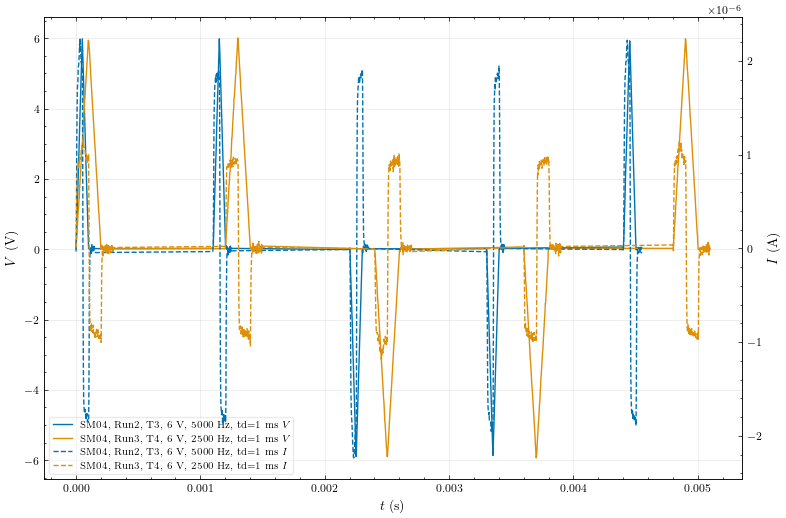

In [97]:
## SM04 PUND - waveforms vs time

fig_sm04_t = plot_PUND([pund_SM04],
     run_nums          = [2, 3],             # run numbers to plot; None = all
    #x_lim             = None,               # (min, max) x-axis limits
    #y_lim_left        = None,               # (min, max) left axis - polarisation / voltage
    #y_lim_right       = None,               # (min, max) right axis - current
    #med_filt          = None,               # median-filter kernel on I (odd int) - kills spikes
    #sigma_filt        = None,               # boxcar window on I - smooths
    #display_points    = False,              # draw a marker at every sample
    #line_width        = None,               # override the style line width
    #markersize        = None,               # override the style marker size
    #plot_key          = True,               # show the legend
    #plot_title        = None,
     export_data       = export_data,        # write the figure (and summary CSV) to output_PMU
     output_PMU        = output_SM04,        # output folder
     fig_name          = 'SM04',             # prefix for the exported file name
     fig_format        = fig_format,         # 'svg' | 'png' | 'tiff' | 'pdf'
     plot_transparency = plot_transparency,  # transparent figure background
    #show              = True,               # render in the notebook; False just returns the figure
    )



PUND extracted parameters:
                              Dataset    Pr+      Qsw+   Vc+     Pr-       Qsw-    Vc-    Pr    2Pr    Vc  Vimprint  Ec+   Ec-   Ec  Eimprint
SM04, Run2, T3, 6 V, 5000 Hz, td=1 ms 0.2855 7.176e-12 3.423 -0.2985 -7.503e-12 -3.511 0.292 0.5841 3.467  -0.04449 1711 -1756 1734    -22.24


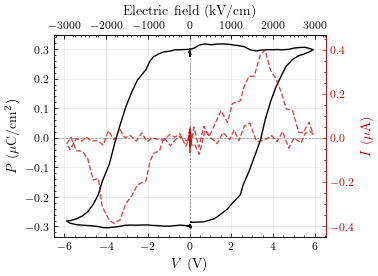

,run,table,our 2Pr,instr dPsw,our Vc,our Ec (kV/cm)
0,2,3,0.584057,0.594975,3.467001,1733.500616
1,3,4,0.617655,0.712996,3.354039,1677.019450


In [ ]:
## SM04 PUND - switching polarisation
# Tables 1-2 were taken on the 100 mA range and are clipped; 3-4 are on 10 uA.

fig_sm04_p, summary_pund_SM04 = plot_PUND_polarisation([pund_SM04],
     run_nums          = [ 2],             # run numbers to plot; None = all
    electrode_area    = None,               # m^2; overrides the area stored on each run
    #film_thickness_nm = None,               # nm; adds the top E-field axis and Ec
    #p_pulse           = None,               # 'last' | 'first' | 'both' - which P pairs with U
    #centre_branches   = True,               # re-reference each half about P = 0
    #align_zero        = True,               # put I = 0 level with P = 0 on the twin axis
    #x_lim             = None,               # (min, max) x-axis limits
    #y_lim_left        = None,               # (min, max) left axis - polarisation / voltage
    #y_lim_right       = None,               # (min, max) right axis - current
    #med_filt          = None,               # median-filter kernel on I (odd int) - kills spikes
    #sigma_filt        = None,               # boxcar window on I - smooths
    #display_points    = False,              # draw a marker at every sample
    #line_width        = None,               # override the style line width
    #markersize        = None,               # override the style marker size
    plot_key          = False,               # show the legend
    #plot_title        = None,
    #print_summary     = True,               # print the extracted-parameter table
     export_data       = export_data,        # write the figure (and summary CSV) to output_PMU
     output_PMU        = output_SM04,        # output folder
     fig_name          = 'SM04',             # prefix for the exported file name
     fig_format        = fig_format,         # 'svg' | 'png' | 'tiff' | 'pdf'
     plot_transparency = plot_transparency,  # transparent figure background
    #show              = True,               # render in the notebook; False just returns the figure
    )

# ours vs what the instrument reported
pd.DataFrame([{'run': m.run_number, 'table': m.metadata['table_no'],
               'our 2Pr': m.extracted_params['2Pr'],
               'instr dPsw': m.instrument_params['dPsw'],
               'our Vc': m.extracted_params.get('Vc'),
               'our Ec (kV/cm)': m.extracted_params.get('Ec')}
              for m in pund_SM04.get([2, 3])[0]])



DHM parameters (as reported by the instrument):
                     Dataset   Pr+    Pr-    Vc+     Vc-  Psw  Pnsw  dPsw  Pvmax+  Pvmax-  Wloss   Pr   2Pr     Vc  Vimprint   Ec+    Ec-    Ec  Eimprint
SM04, Run0, T1, 5 V, 1000 Hz 4.329 -4.372 0.8845 -0.7547 22.9 21.29 1.615   22.09  -22.09  69.94 4.35 8.701 0.8196   0.06494 442.3 -377.3 409.8     32.47


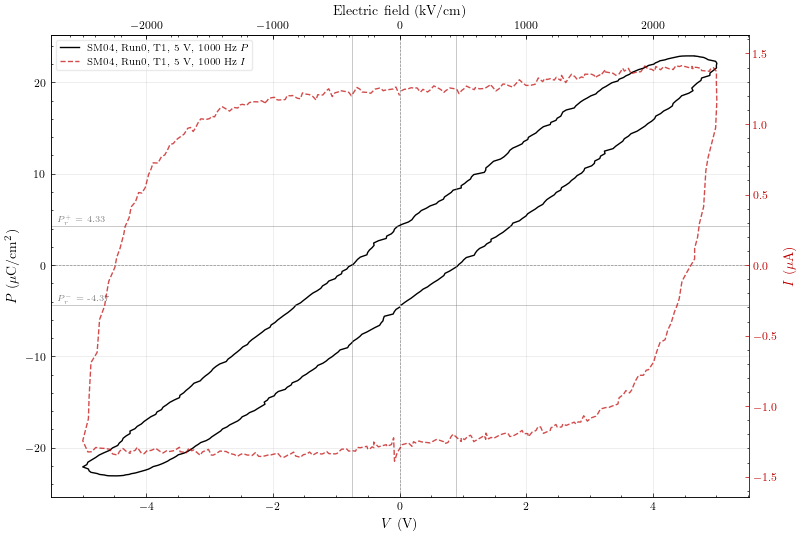

,Dataset,Pr+,Pr-,Vc+,Vc-,Psw,Pnsw,dPsw,Pvmax+,Pvmax-,Wloss,Pr,2Pr,Vc,Vimprint,Ec+,Ec-,Ec,Eimprint
0,"SM04, Run0, T1, 5 V, 1000 Hz",4.32931,-4.3715,0.884525,-0.754655,22.903,21.2883,1.61466,22.0944,-22.0944,69.9392,4.350405,8.70081,0.81959,0.064935,442.2625,-377.3275,409.795,32.4675


In [55]:
## SM04 DHM - hysteresis loop

fig_sm04_dhm, summary_dhm_SM04 = plot_DHM([dhm_SM04],
     run_nums          = [0],                # run numbers to plot; None = all
    #loop              = 1,                  # 1 = main loop, 2/3 = relaxed remanence, 'all' overlays
    #film_thickness_nm = None,               # nm; adds the top E-field axis and Ec
    #plot_current      = True,               # draw the current on a twinned right axis
    #align_zero        = True,               # put I = 0 level with P = 0 on the twin axis
    #annotate          = True,               # mark Pr and Vc on the loop (single dataset only)
    #x_lim             = None,               # (min, max) x-axis limits
    #y_lim_left        = None,               # (min, max) left axis - polarisation / voltage
    #y_lim_right       = None,               # (min, max) right axis - current
    #med_filt          = None,               # median-filter kernel on I (odd int) - kills spikes
    #sigma_filt        = None,               # boxcar window on I - smooths
    #display_points    = False,              # draw a marker at every sample
    #line_width        = None,               # override the style line width
    #markersize        = None,               # override the style marker size
    #plot_key          = True,               # show the legend
    #plot_title        = None,
    #print_summary     = True,               # print the extracted-parameter table
     export_data       = export_data,        # write the figure (and summary CSV) to output_PMU
     output_PMU        = output_SM04,        # output folder
     fig_name          = 'SM04',             # prefix for the exported file name
     fig_format        = fig_format,         # 'svg' | 'png' | 'tiff' | 'pdf'
     plot_transparency = plot_transparency,  # transparent figure background
    #show              = True,               # render in the notebook; False just returns the figure
    )

summary_dhm_SM04


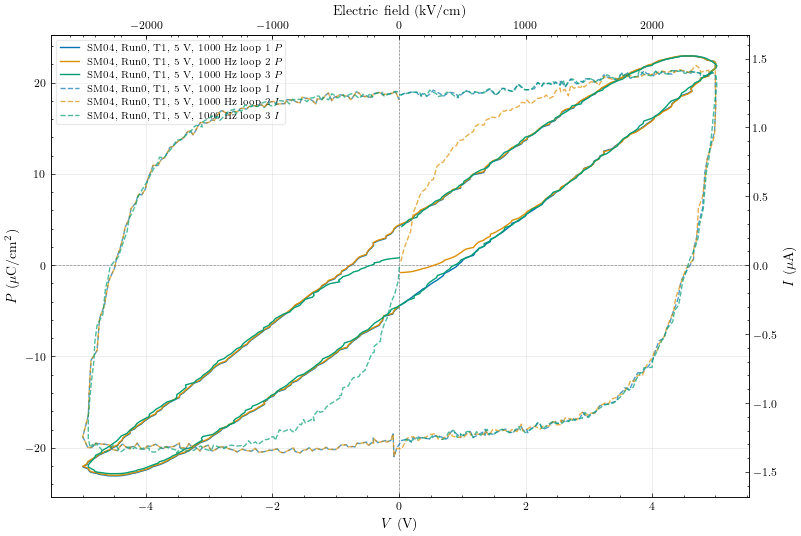

In [56]:
## SM04 DHM - all three loops overlaid
# loop 1 is the main hysteresis loop; 2 and 3 are the relaxed-remanence loops

fig_sm04_loops, _ = plot_DHM([dhm_SM04], run_nums=[0], loop='all',
                             print_summary=False, annotate=False,
                             export_data=export_data, output_PMU=output_SM04,
                             fig_name='SM04_allloops', fig_format=fig_format)


  wrote 49 loop figure(s) to /Users/horatiocox/Desktop/RUG_postdoc/Experiments/AixAcct/SM04/Output/SM04_fatigue_loops

Fatigue summary:
                         Dataset loop type Pr mode  points  cycles max  cycles_max  2Pr_final_pct
SM04, Run1, DHM, to 1e+08 cycles       DHM     raw      49   1.002e+08   1.002e+08          450.7


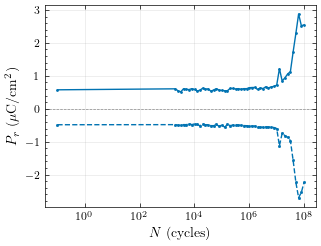

,Dataset,loop type,Pr mode,points,cycles max,cycles_max,2Pr_final_pct
0,"SM04, Run1, DHM, to 1e+08 cycles",DHM,raw,49,100237400.0,100237400.0,450.725393


In [113]:
## SM04 fatigue - remanent polarisation vs cycle count

fig_sm04_fat, summary_fat_SM04 = plot_fatigue([fat_SM04],
    run_nums           = [1], #None,               # run numbers to plot; None = all
    #Pr_mode            = 'raw',              # 'raw' = instrument values, 'extracted' = recomputed (PUND only)
    sub_plots          = True,              # write one figure per cycle point to output_PMU, render none
    #concatenate_stages = False,              # offset each stage by the previous stage final cycle count
    #plot_2Pr           = False,              # plot 2Pr instead of Pr+ and Pr- separately
    #normalise          = False,              # plot as % of the first point
    #x_lim              = None,               # (min, max) x-axis limits
    #y_lim              = None,               # (min, max) y-axis limits
    #display_points     = True,               # draw a marker at every sample
    #line_width         = None,               # override the style line width
    markersize         = 1, #None,               # override the style marker size
    plot_key           = False, #True,               # show the legend
    #plot_title         = None,
    #print_summary      = True,               # print the extracted-parameter table
     export_data        = True, #export_data,        # write the figure (and summary CSV) to output_PMU
     output_PMU         = output_SM04,        # output folder
     fig_name           = 'SM04',             # prefix for the exported file name
     fig_format         = fig_format,         # 'svg' | 'png' | 'tiff' | 'pdf'
     plot_transparency  = plot_transparency,  # transparent figure background
    #show               = True,               # render in the notebook; False just returns the figure
    #sub_plot_kwargs    = None,               # dict of extra kwargs passed to each sub-plot
    )

summary_fat_SM04


  wrote 8 loop figure(s) to /Users/horatiocox/Desktop/RUG_postdoc/Experiments/AixAcct/SM04/Output/SM04_fatigue_loops
  wrote 49 loop figure(s) to /Users/horatiocox/Desktop/RUG_postdoc/Experiments/AixAcct/SM04/Output/SM04_fatigue_loops


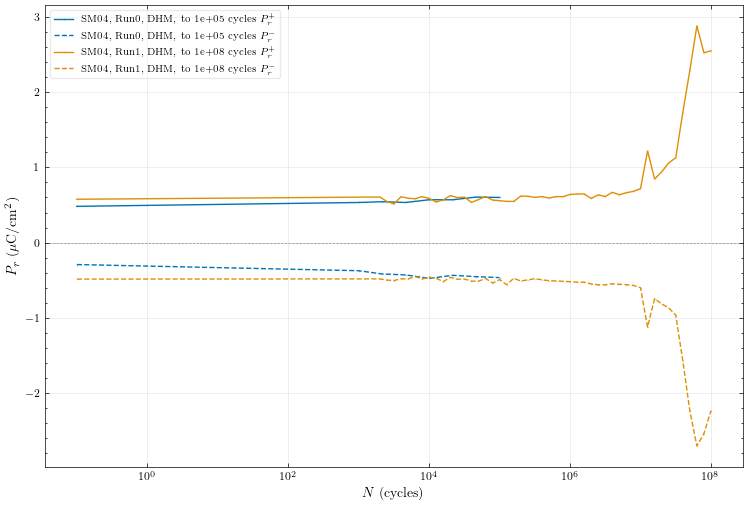

In [58]:
## SM04 fatigue - write every measured loop to disk without rendering them
# One figure per cycle point into <output_SM04>/SM04_fatigue_loops/ (57 in total).
# This is how to check whether a rising Pr is real switching or breakdown.

fig_sub, _ = plot_fatigue([fat_SM04],
                          sub_plots=True,
                          output_PMU=output_SM04,
                          fig_name='SM04',
                          fig_format='png',   # png keeps 57 files manageable
                          print_summary=False,
                          plot_transparency=plot_transparency)


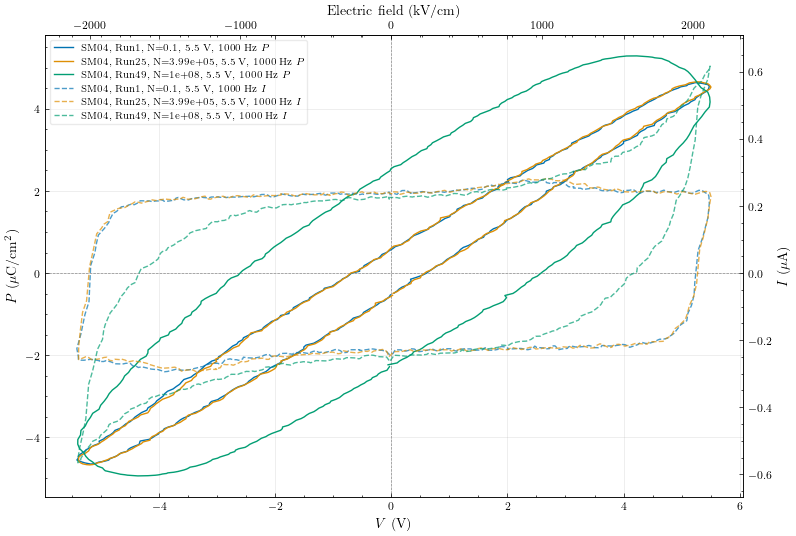

[0.1, 399052.0, 100237000.0]

In [59]:
## SM04 fatigue - inspect individual loops in the notebook
# sub_runs are ordinary PMUdata objects, so plot_DHM takes them directly.

run = fat_SM04[1]                      # the second Result Table
picks = [run.sub_runs[i] for i in (0, len(run.sub_runs) // 2, -1)]

fig_picks, _ = plot_DHM(picks, print_summary=False, annotate=False,
                        plot_transparency=plot_transparency)

[s.metadata['cycles'] for s in picks]   # the cycle count of each


# Keithley (Haoran export) --- PUND, sample H03C5

This workbook arrives **already processed**: the `PUND_Diff` sheet holds the
difference current, charge, polarisation, branch and segment, so nothing is
recomputed --- only the derived scalars are filled in. `Parameters` carries the
waveform settings and the electrode area.

Two current ranges are recorded simultaneously: `channel='I2'` is the fine range
and the default, `channel='I1'` the coarse one, worth checking if the fine range
clipped.

The waveform carries a **+0.5 V offset** --- the device rests at +0.5 V between
pulses rather than at zero. Voltages are plotted as measured, so $V_c^+$ and
$V_c^-$ are genuinely asymmetric and the reported imprint includes that offset.


In [60]:
## Import - Keithley, Haoran export, H03C5

pund_H03C5 = Keithley_Haoran_PUND(data_H03C5,
    #folder_name       = None,     # optional sub-folder under root_folder
    #electrode_area    = None,     # m^2; overrides the area stored on each run
     film_thickness_nm = 20.0,     # nm; adds the top E-field axis and Ec
     sample            = 'H03C5',  # short label prefix used in legends
    #channel           = 'I2',     # 'I2' (fine range, default) | 'I1' (coarse range)
    #transform         = True,     # process on import; False imports the raw data only
    #verbose           = True,     # print the load summary
    )

pund_H03C5[0].metadata     # waveform settings from the Parameters sheet


Keithley_Haoran_PUND: loaded 1 PUND run(s) from /Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/H03C5/Data/PUND


{'source_file': 'Haoran_PUND_tri_Vp4V_off0p5V_rise100us_delay1000us_I11em04_I21em05_20260806_113319.xlsx',
 'rise_time': 0.0001,
 'delay_time': 0.001,
 'offset_ramp_time': 0.0001,
 'Vp': 4.0,
 'offset': 0.5,
 'area_cm2': 3.14e-06,
 'Irange1': 0.0001,
 'Irange2': 1e-05,
 'amplitude_V': 4.0,
 'delay_s': 0.001,
 'channel': 'I2',
 'pund_precomputed': True}

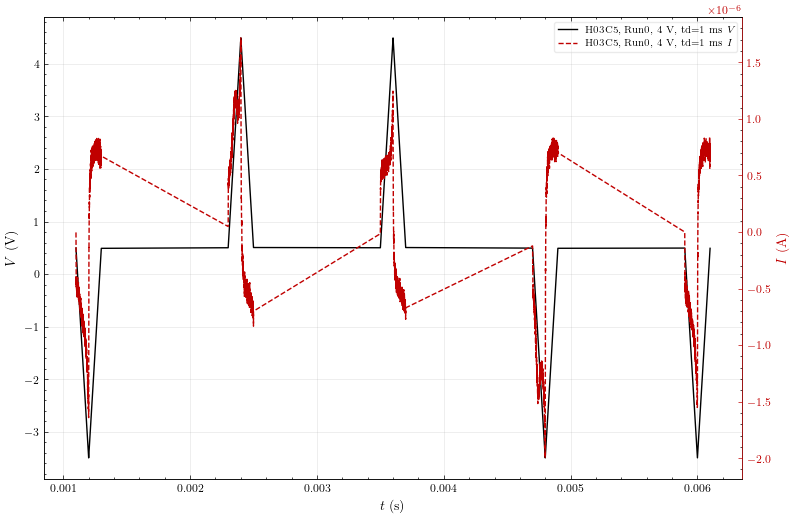

In [61]:
## H03C5 - waveforms vs time

fig_h_t = plot_PUND([pund_H03C5],
    #run_nums          = None,               # run numbers to plot; None = all
    #x_lim             = None,               # (min, max) x-axis limits
    #y_lim_left        = None,               # (min, max) left axis - polarisation / voltage
    #y_lim_right       = None,               # (min, max) right axis - current
    #med_filt          = None,               # median-filter kernel on I (odd int) - kills spikes
    #sigma_filt        = None,               # boxcar window on I - smooths
    #display_points    = False,              # draw a marker at every sample
    #line_width        = None,               # override the style line width
    #markersize        = None,               # override the style marker size
    #plot_key          = True,               # show the legend
    #plot_title        = None,
     export_data       = export_data,        # write the figure (and summary CSV) to output_PMU
     output_PMU        = output_H03C5,       # output folder
     fig_name          = 'H03C5',            # prefix for the exported file name
     fig_format        = fig_format,         # 'svg' | 'png' | 'tiff' | 'pdf'
     plot_transparency = plot_transparency,  # transparent figure background
    #show              = True,               # render in the notebook; False just returns the figure
    )



PUND extracted parameters:
                  Dataset   Pr+      Qsw+   Vc+    Pr-       Qsw-    Vc-   Pr   2Pr    Vc  Vimprint  Ec+    Ec-   Ec  Eimprint
H03C5, Run0, 4 V, td=1 ms 5.422 3.405e-11 3.088 -5.758 -3.616e-11 -1.455 5.59 11.18 2.272    0.8166 1544 -727.6 1136     408.3


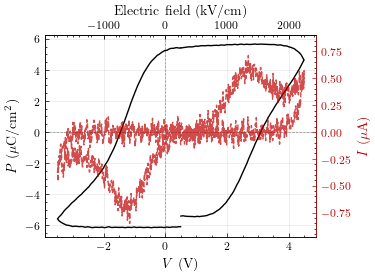

,Dataset,Pr+,Qsw+,Vc+,Pr-,Qsw-,Vc-,Pr,2Pr,Vc,Vimprint,Ec+,Ec-,Ec,Eimprint
0,"H03C5, Run0, 4 V, td=1 ms",5.421848,3.404921e-11,3.088421,-5.757934,-3.615983e-11,-1.455178,5.589891,11.179782,2.271799,0.816622,1544.210547,-727.588835,1135.899691,408.310856


In [ ]:
## H03C5 - switching polarisation
# The loop comes straight from the PUND_Diff sheet; only Pr/Vc/Ec are derived.

fig_h_p, summary_H03C5 = plot_PUND_polarisation([pund_H03C5],
    #run_nums          = None,               # run numbers to plot; None = all
    #electrode_area    = None,               # m^2; overrides the area stored on each run
    #film_thickness_nm = None,               # nm; adds the top E-field axis and Ec
    #p_pulse           = None,               # 'last' | 'first' | 'both' - which P pairs with U
    #centre_branches   = True,               # re-reference each half about P = 0
    #align_zero        = True,               # put I = 0 level with P = 0 on the twin axis
    #x_lim             = None,               # (min, max) x-axis limits
    #y_lim_left        = None,               # (min, max) left axis - polarisation / voltage
    #y_lim_right       = None,               # (min, max) right axis - current
    #med_filt          = None,               # median-filter kernel on I (odd int) - kills spikes
    #sigma_filt        = None,               # boxcar window on I - smooths
    #display_points    = False,              # draw a marker at every sample
    #line_width        = None,               # override the style line width
    #markersize        = None,               # override the style marker size
    plot_key          = False,               # show the legend
    #plot_title        = None,
    #print_summary     = True,               # print the extracted-parameter table
     export_data       =  export_data,        # write the figure (and summary CSV) to output_PMU
     output_PMU        = output_H03C5,       # output folder
     fig_name          = 'H03C5',            # prefix for the exported file name
     fig_format        = fig_format,         # 'svg' | 'png' | 'tiff' | 'pdf'
     plot_transparency = plot_transparency,  # transparent figure background
    #show              = True,               # render in the notebook; False just returns the figure
    )

summary_H03C5


# Collected parameters

Everything derived sits on the run objects, so a table across samples and
instruments is just a comprehension. `extracted_params` holds our values,
`instrument_params` holds whatever the instrument reported, untouched.


In [63]:
## Every PUND run loaded above, side by side

rows = []
for obj in (pund_JT147, pund_SM04, pund_H03C5):
    for m in obj:
        rows.append({'sample': m.sample, 'instrument': m.instrument,
                     'run': m.run_number, 'label': m.plot_string,
                     **{k: v for k, v in m.extracted_params.items()
                        if isinstance(v, (int, float))}})

all_pund = pd.DataFrame(rows)
if export_data:
    all_pund.to_csv(Path(output_SM04) / 'PUND_all_samples.csv', index=False)
all_pund


,sample,instrument,run,label,Pr+,Qsw+,Pr-,Qsw-,Pr,2Pr,Vc,Vimprint,Ec+,Ec-,Ec,Eimprint,Vc+,Vc-
0,JT147,aixacct,0,"JT147, Run0, T1, 2 V, 5000 Hz, td=1 ms",0.076313,1.917891e-12,-0.004113,-1.033670e-13,0.040213,0.080426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,JT147,aixacct,1,"JT147, Run1, T2, 2 V, 5000 Hz, td=1 ms",0.665462,1.672439e-11,-0.731379,-1.838101e-11,0.698420,1.396841,1.049391,-0.090120,479.635444,-569.755193,524.695319,-45.059874,0.959271,-1.139510
2,JT147,aixacct,2,"JT147, Run2, T3, 2 V, 500 Hz, td=1 ms",0.884281,2.222374e-11,-1.008150,-2.533684e-11,0.946216,1.892431,0.785011,-0.041179,371.915993,-413.094649,392.505321,-20.589328,0.743832,-0.826189
3,JT147,aixacct,3,"JT147, Run3, T4, 2 V, 500 Hz, td=1 ms",0.829341,2.084299e-11,-0.959159,-2.410559e-11,0.894250,1.788500,0.745090,-0.079276,332.907011,-412.182833,372.544922,-39.637911,0.665814,-0.824366
4,JT147,aixacct,4,"JT147, Run4, T5, 2 V, 500 Hz, td=1 ms",0.890751,2.238635e-11,-0.969698,-2.437046e-11,0.930225,1.860449,0.783306,-0.037634,372.836198,-410.469788,391.652993,-18.816795,0.745672,-0.820940
5,JT147,aixacct,5,"JT147, Run5, T6, 2 V, 500 Hz, td=1 ms",0.935119,2.350141e-11,-1.053868,-2.648580e-11,0.994493,1.988987,0.813022,-0.049618,381.702375,-431.320031,406.511203,-24.808828,0.763405,-0.862640
6,JT147,aixacct,6,"JT147, Run6, T7, 2 V, 500 Hz, td=1 ms",0.854100,2.146525e-11,-1.083791,-2.723784e-11,0.968946,1.937892,0.797897,-0.012227,392.835031,-405.062333,398.948682,-6.113651,0.785670,-0.810125
7,JT147,aixacct,7,"JT147, Run7, T8, 2 V, 500 Hz, td=100 ms",0.450495,1.132183e-11,-0.573074,-1.440249e-11,0.511784,1.023568,0.775503,-0.060685,357.408997,-418.093746,387.751372,-30.342374,0.714818,-0.836187
8,JT147,aixacct,8,"JT147, Run8, T9, 2 V, 500 Hz, td=1 s",0.396844,9.973496e-12,-0.529201,-1.329989e-11,0.463023,0.926046,0.839819,-0.046067,396.876084,-442.943255,419.909669,-23.033586,0.793752,-0.885887
9,JT147,aixacct,9,"JT147, Run9, T10, 2 V, 500 Hz, td=10 s",0.335137,8.422669e-12,-0.430872,-1.082868e-11,0.383005,0.766009,0.854764,-0.034437,410.163172,-444.600579,427.381875,-17.218704,0.820326,-0.889201


In [64]:
## Relabel runs for publication figures
# Prints each run's index and current label; override with
#   pund_SM04[2].plot_string = 'as-grown'

update_plot_string([pund_JT147, pund_SM04, pund_H03C5, dhm_SM04, fat_SM04])



AixACCT_PUND(folder_path='/Users/horatiocox/Desktop/RUG_postdoc/Experiments/AixAcct/JT147/Data', runs=10)
  [0] JT147, Run0, T1, 2 V, 5000 Hz, td=1 ms
  [1] JT147, Run1, T2, 2 V, 5000 Hz, td=1 ms
  [2] JT147, Run2, T3, 2 V, 500 Hz, td=1 ms
  [3] JT147, Run3, T4, 2 V, 500 Hz, td=1 ms
  [4] JT147, Run4, T5, 2 V, 500 Hz, td=1 ms
  [5] JT147, Run5, T6, 2 V, 500 Hz, td=1 ms
  [6] JT147, Run6, T7, 2 V, 500 Hz, td=1 ms
  [7] JT147, Run7, T8, 2 V, 500 Hz, td=100 ms
  [8] JT147, Run8, T9, 2 V, 500 Hz, td=1 s
  [9] JT147, Run9, T10, 2 V, 500 Hz, td=10 s

AixACCT_PUND(folder_path='/Users/horatiocox/Desktop/RUG_postdoc/Experiments/AixAcct/SM04/Data', runs=4)
  [0] SM04, Run0, T1, 36 V, 5000 Hz, td=1 ms
  [1] SM04, Run1, T2, 6 V, 5000 Hz, td=1 ms
  [2] SM04, Run2, T3, 6 V, 5000 Hz, td=1 ms
  [3] SM04, Run3, T4, 6 V, 2500 Hz, td=1 ms

Keithley_Haoran_PUND(folder_path='/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/H03C5/Data/PUND', runs=1)
  [0] H03C5, Run0, 4 V, td=1 ms

AixACCT_DHM(fo

[AixACCT_PUND(folder_path='/Users/horatiocox/Desktop/RUG_postdoc/Experiments/AixAcct/JT147/Data', runs=10),
 AixACCT_PUND(folder_path='/Users/horatiocox/Desktop/RUG_postdoc/Experiments/AixAcct/SM04/Data', runs=4),
 Keithley_Haoran_PUND(folder_path='/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/H03C5/Data/PUND', runs=1),
 AixACCT_DHM(folder_path='/Users/horatiocox/Desktop/RUG_postdoc/Experiments/AixAcct/SM04/Data', runs=14),
 AixACCT_Fatigue(folder_path='/Users/horatiocox/Desktop/RUG_postdoc/Experiments/AixAcct/SM04/Data', runs=2)]

# aixACCT --- PUND + DHM + Fatigue, sample SM06



In [117]:
## Import all three measurement types from the one folder

pund_SM06 = AixACCT_PUND(data_SM06,
    #folder_name       = None,    # optional sub-folder under root_folder
    electrode_area    = np.pi*((40e-6)/2)**2, #None,    # m^2; overrides the area stored on each run
    #film_thickness_nm = None,    # nm; adds the top E-field axis and Ec
     sample            = 'SM06',  # short label prefix used in legends
    #p_pulse           = 'last',  # 'last' | 'first' | 'both' - which P pairs with U
    #centre_branches   = True,    # re-reference each half about P = 0
    #med_filt          = None,    # median-filter kernel on I (odd int) - kills spikes
    #sigma_filt        = None,    # boxcar window on I - smooths
    #transform         = True,    # process on import; False imports the raw data only
    #verbose           = True,    # print the load summary
    )

# dhm_SM06 = AixACCT_DHM(data_SM06,
#     #folder_name       = None,    # optional sub-folder under root_folder
#     #electrode_area    = None,    # m^2; overrides the area stored on each run
#     #film_thickness_nm = None,    # nm; adds the top E-field axis and Ec
#      sample            = 'SM06',  # short label prefix used in legends
#     #loop              = 1,       # 1 = main loop, 2/3 = relaxed remanence, 'all' overlays
#     #transform         = True,    # process on import; False imports the raw data only
#     #verbose           = True,    # print the load summary
#     )

# fat_SM06 = AixACCT_Fatigue(data_SM06,
#     #folder_name       = None,    # optional sub-folder under root_folder
#     #electrode_area    = None,    # m^2; overrides the area stored on each run
#     #film_thickness_nm = None,    # nm; adds the top E-field axis and Ec
#      sample            = 'SM06',  # short label prefix used in legends
#     #Pr_mode           = 'raw',   # 'raw' = instrument values, 'extracted' = recomputed (PUND only)
#     #loop              = 1,       # 1 = main loop, 2/3 = relaxed remanence, 'all' overlays
#     #transform         = True,    # process on import; False imports the raw data only
#     #verbose           = True,    # print the load summary
#     )


AixACCT_PUND: loaded 7 PUND run(s) from /Users/horatiocox/Desktop/RUG_postdoc/Experiments/AixAcct/SM06/Data


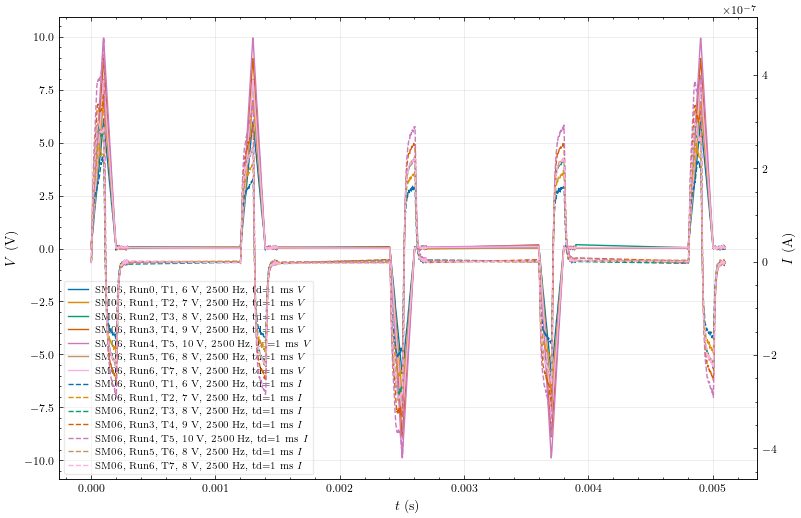

In [118]:
## SM04 PUND - waveforms vs time

fig_sm04_t = plot_PUND([pund_SM06],
     #run_nums          = [2, 3],             # run numbers to plot; None = all
    #x_lim             = None,               # (min, max) x-axis limits
    #y_lim_left        = None,               # (min, max) left axis - polarisation / voltage
    #y_lim_right       = None,               # (min, max) right axis - current
    #med_filt          = None,               # median-filter kernel on I (odd int) - kills spikes
    #sigma_filt        = None,               # boxcar window on I - smooths
    #display_points    = False,              # draw a marker at every sample
    #line_width        = None,               # override the style line width
    #markersize        = None,               # override the style marker size
    #plot_key          = True,               # show the legend
    #plot_title        = None,
     export_data       = export_data,        # write the figure (and summary CSV) to output_PMU
     output_PMU        = output_SM06,        # output folder
     fig_name          = 'SM06',             # prefix for the exported file name
     fig_format        = fig_format,         # 'svg' | 'png' | 'tiff' | 'pdf'
     plot_transparency = plot_transparency,  # transparent figure background
    #show              = True,               # render in the notebook; False just returns the figure
    )



PUND extracted parameters:
                              Dataset    Pr+      Qsw+   Vc+     Pr-       Qsw-    Vc-     Pr    2Pr    Vc  Vimprint  Ec+   Ec-   Ec  Eimprint
SM06, Run6, T7, 8 V, 2500 Hz, td=1 ms 0.1623 4.078e-12 5.032 -0.1515 -3.807e-12 -6.053 0.1569 0.3137 5.542   -0.5102 1935 -2328 2132    -196.2


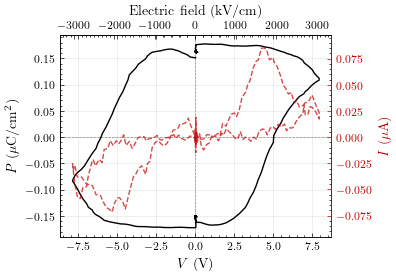

,run,table,our 2Pr,instr dPsw,our Vc,our Ec (kV/cm)
0,2,3,0.584057,0.594975,3.467001,1733.500616
1,3,4,0.617655,0.712996,3.354039,1677.019450


In [ ]:
## SM04 PUND - switching polarisation
# Tables 1-2 were taken on the 100 mA range and are clipped; 3-4 are on 10 uA.

fig_sm06_p, summary_pund_SM06 = plot_PUND_polarisation([pund_SM06],
    run_nums          = [ 6],             # run numbers to plot; None = all
    electrode_area    = None,               # m^2; overrides the area stored on each run
    #film_thickness_nm = None,               # nm; adds the top E-field axis and Ec
    #p_pulse           = None,               # 'last' | 'first' | 'both' - which P pairs with U
    #centre_branches   = True,               # re-reference each half about P = 0
    #align_zero        = True,               # put I = 0 level with P = 0 on the twin axis
    #x_lim             = None,               # (min, max) x-axis limits
    #y_lim_left        = None,               # (min, max) left axis - polarisation / voltage
    #y_lim_right       = None,               # (min, max) right axis - current
    #med_filt          = None,               # median-filter kernel on I (odd int) - kills spikes
    #sigma_filt        = None,               # boxcar window on I - smooths
    #display_points    = False,              # draw a marker at every sample
    #line_width        = None,               # override the style line width
    #markersize        = None,               # override the style marker size
    plot_key          = False,               # show the legend
    #plot_title        = None,
    #print_summary     = True,               # print the extracted-parameter table
     export_data       = export_data,        # write the figure (and summary CSV) to output_PMU
     output_PMU        = output_SM06,        # output folder
     fig_name          = 'SM06',             # prefix for the exported file name
     fig_format        = fig_format,         # 'svg' | 'png' | 'tiff' | 'pdf'
     plot_transparency = plot_transparency,  # transparent figure background
    #show              = True,               # render in the notebook; False just returns the figure
    )

# ours vs what the instrument reported
pd.DataFrame([{'run': m.run_number, 'table': m.metadata['table_no'],
               'our 2Pr': m.extracted_params['2Pr'],
               'instr dPsw': m.instrument_params['dPsw'],
               'our Vc': m.extracted_params.get('Vc'),
               'our Ec (kV/cm)': m.extracted_params.get('Ec')}
              for m in pund_SM04.get([2, 3])[0]])
